In [109]:
import os
import configparser
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

## Get data

In [2]:
#set filepaths
project_root = os.path.abspath(os.getcwd())
root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
config_file =  os.path.join(root, 'config.cfg')

# geodata for shapefiles
config = configparser.ConfigParser()
config.read(config_file)
gdata_root = config['geodata']['path']

### Get London shapefiles

In [3]:
## Load london boroughs shapefile
london = gpd.read_file(os.path.join(gdata_root, 'london-shapefiles\\London_Borough_Excluding_MHW.shp'))
london = london.to_crs(4326)

# convert to CRS to have units in meters in the UK
_crs = "EPSG:32630"
london_reprojected = london.to_crs(_crs)

### Collect OSM data

Tutorial: https://williamthyer.github.io/posts/2021/4/bike_networks/

Updated code to align with OSMNX 2.0 release

In [3]:
import osmnx as ox

In [23]:
def get_cycleways_polygon(polygon): 
    
    # Configuring osmnx
    ox.settings.useful_tags_way.extend(["cycleway"])
        
    # Querying for roads and bike trails
    cycleways = ox.graph_from_polygon(polygon, network_type='bike', simplify=False)
    
    # Finding all non-cycleways in the network
    non_cycleways = [(u, v, k) for  u, v, k, d  in  
                     cycleways.edges(keys=True, data=True) 
                     if  not ('cycleway'  in  d  or  
                              d['highway']=='cycleway'
                              )]
   
    # Remove non-cycleways and isolated nodes
    cycleways.remove_edges_from(non_cycleways)
   
    return cycleways

In [24]:
osm_cycleways_df = []
osm_stats = {"NAME": [], "total_cycleways":[], "total_roads":[], "ratio": []}

#loop through all boroughs and append networks stats + cycleway geometries
for borough in london["NAME"].unique():
    polygon = london[london["NAME"]==borough]["geometry"].iloc[0]
    cycleways = get_cycleways_polygon(polygon)
    roads =  ox.graph_from_polygon(polygon, network_type='drive', simplify=True)
    cycleway_length = ox.basic_stats(cycleways)['edge_length_total']
    roads_length = ox.basic_stats(roads)['edge_length_total']
    osm_stats["total_cycleways"].append(cycleway_length)
    osm_stats["total_roads"].append(roads_length)
    rc_ratio = roads_length/cycleway_length
    osm_stats["NAME"].append(borough)
    osm_stats["ratio"].append(rc_ratio)

    #append cycleways geos
    cycleways_df_single = ox.convert.graph_to_gdfs(cycleways, nodes=False, edges=True)
    cols = ['highway',  'cycleway', 'length', 'geometry']
    cycleways_df_single = cycleways_df_single[cols].reset_index(drop=True)
    cycleways_df_single["NAME"] = borough
    osm_cycleways_df.append(cycleways_df_single)

In [ ]:
#save cycleways to csv file
osm_cycleways_all = pd.concat(osm_cycleways_df, ignore_index=True)
osm_cycleways_all = osm_cycleways_all.rename_geometry('WKT')
osm_cycleways_all.to_csv("osm_cycleways_by_borough.csv", index=False)

#save stats to csv file
osm_stats_df = pd.DataFrame(osm_stats)
osm_stats_df.to_csv("osm_road_cycleways_stats.csv", index=False)

#osm_stats_df

### Get prepared OSM data

Load prepared data sets so we don't have to rerun OSMnx code each time.

In [71]:
# load preprocessed csv file
osm_stats_df = pd.read_csv("osm_road_cycleways_stats.csv").rename(columns={"ratio":"road_cycleway_ratio"})
osm_cycleways_gdf = gpd.read_file("osm_cycleways_by_borough.csv")
osm_cycleways_gdf = osm_cycleways_gdf.set_crs('EPSG:4326')

### TfL cycle routes

In [53]:
# load TFL cycle routes
tfl_cycle_routes = gpd.GeoDataFrame.from_file('TfL_CycleRoutes.json')

#load summary stats for tfl cycle routes
tfl_cycle_routes_stats = pd.read_csv("tfl_cycle_routes_stats.csv")
tfl_cycle_routes_stats.head()

,NAME,Open,Planned,Total
0,Kingston upon Thames,15.1,1.6,16.7
1,Croydon,0.0,0.0,0.0
2,Bromley,0.0,2.4,2.4
3,Hounslow,7.9,5.3,13.2
4,Ealing,16.1,5.7,21.8


### Secure cycle storage

In [56]:
#load cycle hangar stats
hangar_stats = pd.read_csv("cycle_hangar_stats.csv")
hangar_stats.head()

,NAME,Total
0,Kingston upon Thames,77
1,Croydon,131
2,Bromley,37
3,Hounslow,29
4,Ealing,69


### Get cycling rates

In [101]:
#read in each tab and merge into one table
rates = pd.read_excel("cw0302-proportion-of-adults-that-cycle-by-frequency-purpose-and-local-authority.xlsx",
                       sheet_name="CW0302", skiprows=4)
rates = rates[rates["ONS Code"].isin(london["GSS_CODE"])].reset_index(drop=True)
# replace missing data
years = ['2016', '2017', '2018','2019', '2020', '2021', '2022', '2023']
for year in years:
    rates[year] = rates[year].replace("[u]", np.nan)
rates.head()

,ONS Code,Area name,Class,Mode,Purpose,Frequency,2016,2017,2018,2019,2020,2021,2022,2023
0,E09000007,Camden,London Borough,Cycling,Any,At least once per month,17.9,21.3,20.2,18.8,22.3,22.6,20.6,22.5
1,E09000007,Camden,London Borough,Cycling,Any,At least once per week,13.9,15.3,14.5,15.9,15.6,17.5,16.5,17.5
2,E09000007,Camden,London Borough,Cycling,Any,At least 3 times per week,8.4,7.6,10.1,10.6,7.8,8.6,10.0,8.3
3,E09000007,Camden,London Borough,Cycling,Any,At least 5 times per week,6.4,NaN,6.7,NaN,NaN,NaN,5.9,NaN
4,E09000007,Camden,London Borough,Cycling,Leisure,At least once per month,11.9,14.1,13.3,12.6,15.2,13.6,11.3,16.1


### Borough household numbers

In [64]:
#read in each tab and merge into one table
households = pd.read_excel("roundedhouseholdestimates2023.xlsx",
                       sheet_name="2023", skiprows=6, 
                       usecols=[0,1,2],
                       names=["GSS_CODE", "NAME", "no_households"]
                         )

households.head()

,GSS_CODE,NAME,no_households
0,E06000047,County Durham,239900
1,E06000005,Darlington,47600
2,E06000001,Hartlepool,39700
3,E06000002,Middlesbrough,57900
4,E06000057,Northumberland,148400


### Get funding bids

Source: Data gathered by Sian Berry AM, Green Party Member of the London Assembly via Freedom of Information Request.

'Winning Better Borough Transport Plans'. Analysis of the latest borough bids and awards for local delivery plans 2023-25, February 2024

[Pdf download here](https://www.london.gov.uk/sites/default/files/2024-02/2024_02_SIAN_BERRY_WINNING_BETTER_BOROUGH_TRANSPORT_PLANS.pdf)

In [82]:
funding = pd.read_csv("transport_bids.csv",
                        skiprows=2, usecols=[0,1,2,3], 
                        header=None,
                        names=["GSS_CODE","NAME", "transport_bid", "transport_funding"])
funding.head()

,GSS_CODE,NAME,transport_bid,transport_funding
0,E09000002,Barking & Dagenham,555.0,230.0
1,E09000003,Barnet,809.0,80.0
2,E09000004,Bexley,100.0,30.0
3,E09000005,Brent,0.0,0.0
4,E09000006,Bromley,21.0,5.0


## Process data

In [149]:
#start with London borough shapefile
gdf = london[['NAME', 'GSS_CODE', 'HECTARES', 'NONLD_AREA', 'ONS_INNER', 'geometry']]

#add # of households
gdf = pd.merge(gdf, households[["GSS_CODE", "no_households"]], left_on="GSS_CODE", right_on="GSS_CODE", how="left")

#add funding
gdf = pd.merge(gdf, funding[["GSS_CODE", "transport_bid", "transport_funding"]], left_on="GSS_CODE", right_on="GSS_CODE", how="left")
gdf["funding_perk_household"] = gdf["transport_funding"] / gdf["no_households"]*1000

#add osm stats
gdf = pd.merge(gdf, osm_stats_df.rename(columns=lambda x: f"osm_{x}" if x != 'NAME' else x), 
               left_on="NAME", right_on="NAME", how="left",)
gdf["osm_cycle_road_ratio"] = gdf["osm_total_cycleways"] / gdf["osm_total_roads"] *100

#add tfl stats
gdf = pd.merge(gdf, tfl_cycle_routes_stats.rename(columns=lambda x: f"tfl_{x.lower()}" if x != 'NAME' else x), 
               left_on="NAME", right_on="NAME", how="left",)
gdf["tfl_cycle_road_ratio"] =  (gdf["tfl_open"]*1000) / (gdf["osm_total_roads"]) *100

#add hangar stats
gdf = pd.merge(gdf, hangar_stats.rename(columns=lambda x: f"hangar_{x.lower()}" if x != 'NAME' else x), 
               left_on="NAME", right_on="NAME", how="left",)
gdf["hangar_perk_household"] = gdf["hangar_total"] / gdf["no_households"]*1000

gdf.head()

,NAME,GSS_CODE,HECTARES,NONLD_AREA,ONS_INNER,geometry,no_households,transport_bid,transport_funding,funding_perk_household,osm_total_cycleways,osm_total_roads,osm_road_cycleway_ratio,osm_cycle_road_ratio,tfl_open,tfl_planned,tfl_total,tfl_cycle_road_ratio,hangar_total,hangar_perk_household
0,Kingston upon Thames,E09000021,3726.117,0.000,F,"POLYGON ((-0.33066 51.32901, -0.33057 51.32909...",72600,0.0,0.0,0.000000,67121.677362,6.469725e+05,9.638801,10.374735,15.1,1.6,16.7,2.333948,77,1.060606
1,Croydon,E09000008,8649.441,0.000,F,"POLYGON ((-0.06399 51.31864, -0.06405 51.31861...",166000,0.0,80.0,0.481928,68759.292136,1.519725e+06,22.102102,4.524456,0.0,0.0,0.0,0.000000,131,0.789157
2,Bromley,E09000006,15013.487,0.000,F,"POLYGON ((0.01216 51.29960, 0.01199 51.29979, ...",148700,21.0,5.0,0.033625,80419.021249,1.780396e+06,22.138995,4.516917,0.0,2.4,2.4,0.000000,37,0.248823
3,Hounslow,E09000018,5658.541,60.755,F,"POLYGON ((-0.24454 51.48870, -0.24466 51.48868...",98800,804.0,225.0,2.277328,134713.756341,9.509014e+05,7.058681,14.166953,7.9,5.3,13.2,0.830791,29,0.293522
4,Ealing,E09000009,5554.428,0.000,F,"POLYGON ((-0.41181 51.53408, -0.41186 51.53413...",138300,540.0,115.0,0.831526,166123.817524,1.100103e+06,6.622187,15.100752,16.1,5.7,21.8,1.463499,69,0.498915


## Data viz

In [159]:
def filter_rates(purpose, frequency):
    filter = (rates["Purpose"] == purpose) & (rates["Frequency"]== frequency)
    rates_f = rates[filter]
    return rates_f

### More cycle lanes = more cyclists?

What makes people cycle regularly?

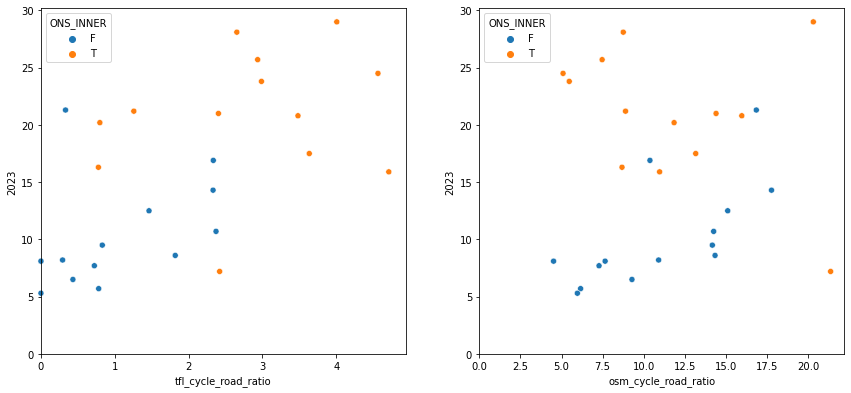

In [178]:
rates_f = filter_rates("Any", "At least once per week")
data = pd.merge(gdf, rates_f[["ONS Code", "2023"]], left_on="GSS_CODE", right_on="ONS Code", how="left")

#setup-------------------------------
fig, axes = plt.subplots(1,2, figsize=(12,6))
plt.subplots_adjust(hspace=0.2, left=0.07, top=0.85, bottom=0.05, right=1)

#plot data ---------------------------------
sns.scatterplot(data=data, x="tfl_cycle_road_ratio", y="2023", hue="ONS_INNER", ax=axes[0],
                clip_on=False)
sns.scatterplot(data=data, x="osm_cycle_road_ratio", y="2023", hue="ONS_INNER", ax=axes[1])

#format axes ---------------------------------
for ax in axes:
    ax.set_ylim(ymin=0)
    ax.set_xlim(xmin=0)

## Exploration

In [ ]:
def filter_rates(purpose, frequency):
    filter = (rates["Purpose"] == purpose) & (rates["Frequency"]== frequency)
    rates_f = rates[filter]
    return rates_f

rates_f = filter_rates("Any", "At least once per week")
rates_f.head()

,ONS Code,Area name,Class,Mode,Purpose,Frequency,2016,2017,2018,2019,2020,2021,2022,2023
1,E09000007,Camden,London Borough,Cycling,Any,At least once per week,13.9,15.3,14.5,15.9,15.6,17.5,16.5,17.5
13,E09000001,City of London,Inner London,Cycling,Any,At least once per week,21.7,14.6,NaN,13.4,15.7,13.2,NaN,NaN
25,E09000012,Hackney,London Borough,Cycling,Any,At least once per week,30.1,26.0,25.3,22.8,32.6,23.4,28.0,29.0
37,E09000013,Hammersmith and Fulham,London Borough,Cycling,Any,At least once per week,26.8,19.3,19.8,18.4,22.7,22.5,23.8,28.1
49,E09000014,Haringey,London Borough,Cycling,Any,At least once per week,13.8,15.1,11.2,15.0,14.2,12.1,12.0,20.2


<AxesSubplot:xlabel='osm_cycle_road_ratio', ylabel='2023'>

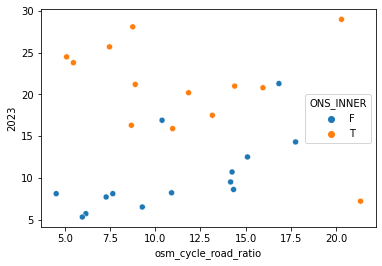

In [145]:
rates_f = filter_rates("Any", "At least once per week")
data = pd.merge(gdf, rates_f[["ONS Code", "2023"]], left_on="GSS_CODE", right_on="ONS Code", how="left")
sns.scatterplot(data=data, x="osm_cycle_road_ratio", y="2023", hue="ONS_INNER")

<AxesSubplot:xlabel='hangar_perk_household', ylabel='2023'>

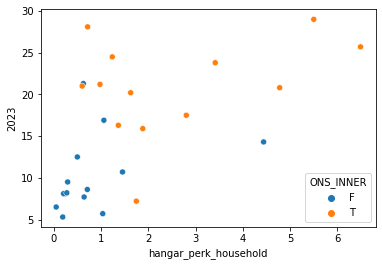

In [136]:
rates_f = filter_rates("Any", "At least once per week")
data = pd.merge(gdf, rates_f[["ONS Code", "2023"]], left_on="GSS_CODE", right_on="ONS Code", how="left")
sns.scatterplot(data=data, x="hangar_perk_household", y="2023", hue="ONS_INNER")

<AxesSubplot:xlabel='hangar_x_ratio', ylabel='2023'>

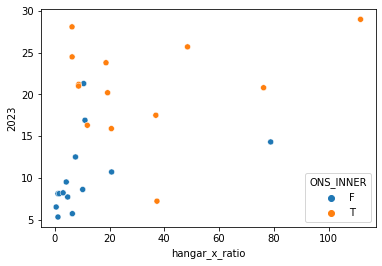

In [146]:
rates_f = filter_rates("Any", "At least once per week")
data = pd.merge(gdf, rates_f[["ONS Code", "2023"]], left_on="GSS_CODE", right_on="ONS Code", how="left")
data["hangar_x_ratio"] = data["hangar_perk_household"] * data["osm_cycle_road_ratio"]
sns.scatterplot(data=data, x="hangar_x_ratio", y="2023", hue="ONS_INNER")

<AxesSubplot:xlabel='tfl_cycle_road_ratio', ylabel='2023'>

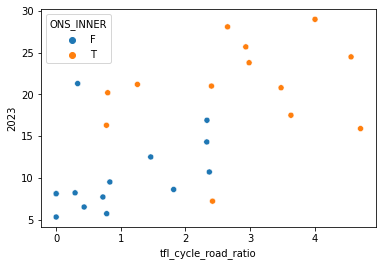

In [152]:
rates_f = filter_rates("Any", "At least once per week")
data = pd.merge(gdf, rates_f[["ONS Code", "2023"]], left_on="GSS_CODE", right_on="ONS Code", how="left")
sns.scatterplot(data=data, x="tfl_cycle_road_ratio", y="2023", hue="ONS_INNER")

## Playground

In [ ]:
city_name = 'Lewisham'
polygon = london[london["NAME"]==city_name]["geometry"].iloc[0]
cycleways = get_cycleways_polygon(polygon)
roads =  ox.graph_from_polygon(polygon, network_type='drive', simplify=True)

In [51]:
cycleways = get_cycleways_polygon(polygon)
roads =  ox.graph_from_polygon(polygon, network_type='drive', simplify=True)

In [49]:
#Bexley
cycleways_stats = ox.basic_stats(cycleways)
roads_stats = ox.basic_stats(roads)

cycleway_length = cycleways_stats['edge_length_total']
roads_length = roads_stats['edge_length_total']

rc_ratio = roads_length/cycleway_length
rc_ratio

13.921139808794827

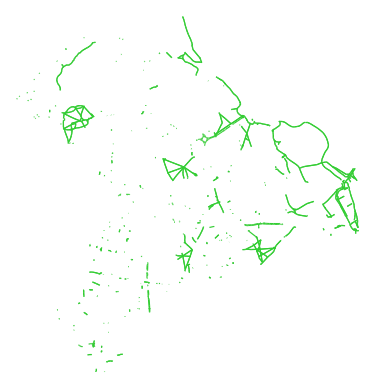

(<Figure size 640x480 with 1 Axes>, <Axes: >)

In [42]:
# Get cycleways network
# Plotting
fig, ax = plt.subplots()
ox.plot_graph(
	cycleways,
	ax=ax,
	node_size=0,
	edge_linewidth=.85,
	edge_color='limegreen')